# Smart Healthcare Prediction System — Heart Disease Risk Assessment
**Course:** Machine Learning

**Name:** Noor Fatima 

**Roll No:** Fa23/BSCS/443 

**Section:** K

**University:** Lahore Garrison University 

**Semester:** 6th 


---
### Project Overview
This project develops a Smart Healthcare Prediction System for Heart Disease Risk Assessment using clinical and lifestyle data. Ensemble machine learning techniques — Random Forest, Gradient Boosting, AdaBoost, and Voting Classifier — are applied to improve prediction accuracy. The system classifies patients as having heart disease (1) or not (0), and includes EDA, preprocessing, model evaluation, comparison, feature importance, and a real-time prediction function.

---

---
## PHASE 1 — ENVIRONMENT SETUP

This phase installs all required Python libraries and imports them. These tools handle data processing, machine learning model training, visualization, and performance evaluation.

### Step 1 — Install Required Libraries
Install all necessary packages. Run this cell once before anything else.

In [1]:
# ─── Install required libraries (run once) ───
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

# ─── Core Libraries ───
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn: Preprocessing & Utilities ───
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer

# ─── Scikit-learn: Ensemble Models ───
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier
)

# ─── Scikit-learn: Evaluation Metrics ───
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ─── SMOTE for class imbalance ───
from imblearn.over_sampling import SMOTE

# ─── Global plot settings ───
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#2563EB', '#DC2626']   # Blue = No Disease, Red = Disease

print("All libraries imported successfully!")

All libraries imported successfully!


---
## PHASE 2 — DATA LOADING

This phase loads the Heart Disease dataset into a pandas DataFrame and performs an initial inspection of its structure, columns, data types, and any missing values.

### Step 2 — Load the Dataset
Read the CSV file and display the first few rows to confirm it loaded correctly.

In [3]:
df = pd.read_csv('heart_disease_dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset loaded successfully!
Shape: (10000, 17)  →  10000 rows, 17 columns



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,40.0,0.0,2.0,162.0,258.0,0.0,1.0,191.0,0.0,4.100000,3.0,0.0,6.0,0.0,0.0,39.0,1.0
1,68.0,1.0,1.0,180.0,590.0,0.0,0.0,116.0,0.0,4.000000,1.0,2.0,3.0,0.0,1.0,16.5,1.0
2,37.0,0.0,3.0,196.0,248.0,0.0,2.0,106.0,0.0,1.926303,2.0,2.0,3.0,1.0,1.0,20.0,1.0
3,51.0,1.0,1.0,94.0,444.0,0.0,0.0,197.0,0.0,0.700000,2.0,1.0,3.0,0.0,0.0,20.1,1.0
4,70.0,1.0,2.0,194.0,512.0,1.0,1.0,174.0,0.0,0.200000,1.0,3.0,3.0,0.0,0.0,31.7,0.0


### Step 3 — Inspect Columns, Data Types, and Feature Descriptions
Understand what each feature means and verify the correct data types are assigned.

In [4]:
print("=" * 50)
print("Column Names and Data Types")
print("=" * 50)
print(df.dtypes)
print(f"\nTotal Features : {df.shape[1] - 1}")
print(f"Target Column  : heart_disease")

# Feature descriptions
feature_info = {
    'age'         : 'Patient age in years',
    'sex'         : '1 = Male, 0 = Female',
    'cp'          : 'Chest pain type (1–4)',
    'trestbps'    : 'Resting blood pressure (mm Hg)',
    'chol'        : 'Serum cholesterol (mg/dl)',
    'fbs'         : 'Fasting blood sugar > 120 mg/dl (1=True)',
    'restecg'     : 'Resting ECG results (0, 1, 2)',
    'thalach'     : 'Maximum heart rate achieved',
    'exang'       : 'Exercise induced angina (1=Yes)',
    'oldpeak'     : 'ST depression induced by exercise',
    'slope'       : 'Slope of peak exercise ST segment',
    'ca'          : 'Number of major vessels (0–3)',
    'thal'        : 'Thalassemia type',
    'smoking'     : '1 = Smoker, 0 = Non-smoker',
    'diabetes'    : '1 = Has diabetes, 0 = No diabetes',
    'bmi'         : 'Body Mass Index',
    'heart_disease': '1 = Heart disease present, 0 = Absent (TARGET)'
}
print("\n=" * 5)
print("Feature Descriptions")
print("=" * 50)
for col, desc in feature_info.items():
    print(f"  {col:<16} → {desc}")

Column Names and Data Types
age              float64
sex              float64
cp               float64
trestbps         float64
chol             float64
fbs              float64
restecg          float64
thalach          float64
exang            float64
oldpeak          float64
slope            float64
ca               float64
thal             float64
smoking          float64
diabetes         float64
bmi              float64
heart_disease    float64
dtype: object

Total Features : 16
Target Column  : heart_disease

=
=
=
=
=
Feature Descriptions
  age              → Patient age in years
  sex              → 1 = Male, 0 = Female
  cp               → Chest pain type (1–4)
  trestbps         → Resting blood pressure (mm Hg)
  chol             → Serum cholesterol (mg/dl)
  fbs              → Fasting blood sugar > 120 mg/dl (1=True)
  restecg          → Resting ECG results (0, 1, 2)
  thalach          → Maximum heart rate achieved
  exang            → Exercise induced angina (1=Yes)
  oldpea

### Step 4 — Missing Values Analysis
Identify which columns have missing data and what percentage is missing. This guides our imputation strategy in Phase 4.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count'  : missing,
    'Missing %'      : missing_pct
})

print("Missing Values Report")
print("=" * 35)
print(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# ── Inject a small amount of artificial NaNs to demonstrate KNN Imputer ──
# (Real-world robustness: we show the imputer works even when values go missing)
import random
random.seed(42)
df_with_nan = df.copy()
cols_to_nan = ['chol', 'trestbps', 'bmi', 'thalach']
for col in cols_to_nan:
    nan_idx = random.sample(range(len(df_with_nan)), k=30)
    df_with_nan.loc[nan_idx, col] = np.nan

print(f"\nAfter injecting synthetic missing values (for KNN demo):")
print(df_with_nan[cols_to_nan].isnull().sum())

Missing Values Report
               Missing Count  Missing %
age                        0        0.0
sex                        0        0.0
cp                         0        0.0
trestbps                   0        0.0
chol                       0        0.0
fbs                        0        0.0
restecg                    0        0.0
thalach                    0        0.0
exang                      0        0.0
oldpeak                    0        0.0
slope                      0        0.0
ca                         0        0.0
thal                       0        0.0
smoking                    0        0.0
diabetes                   0        0.0
bmi                        0        0.0
heart_disease              0        0.0

Total missing values: 0

After injecting synthetic missing values (for KNN demo):
chol        30
trestbps    30
bmi         30
thalach     30
dtype: int64


### Step 5 — Target Class Distribution (Imbalance Check)
Check the split between patients with and without heart disease. Class imbalance affects model training and requires SMOTE correction.

In [6]:
class_counts = df['heart_disease'].value_counts()
class_pct    = df['heart_disease'].value_counts(normalize=True) * 100

print("Target Class Distribution")
print("=" * 35)
print(f"  No Heart Disease (0) : {class_counts[0]:>5}  ({class_pct[0]:.1f}%)")
print(f"  Heart Disease    (1) : {class_counts[1]:>5}  ({class_pct[1]:.1f}%)")
print(f"  Imbalance Ratio      : {class_counts[0]/class_counts[1]:.2f} : 1")
print("\n→ Mild imbalance detected. SMOTE will be applied in preprocessing.")

Target Class Distribution
  No Heart Disease (0) :  5433  (54.3%)
  Heart Disease    (1) :  4567  (45.7%)
  Imbalance Ratio      : 1.19 : 1

→ Mild imbalance detected. SMOTE will be applied in preprocessing.


### Step 6 — Basic Statistical Summary
Review mean, median, std, min, max of all numerical features to spot anomalies or extreme values.

In [7]:
print("Basic Statistical Summary")
print("=" * 70)
df.describe().T.style.background_gradient(cmap='Blues')

Basic Statistical Summary


,count,mean,std,min,25%,50%,75%,max
age,10000.000000,52.876400,13.796860,21.000000,41.000000,53.000000,65.000000,82.000000
sex,10000.000000,0.551500,0.497366,0.000000,0.000000,1.000000,1.000000,1.000000
cp,10000.000000,2.486100,1.112084,0.000000,1.000000,2.000000,3.000000,5.000000
trestbps,10000.000000,145.495400,31.935744,71.000000,118.000000,146.000000,173.000000,214.000000
chol,10000.000000,345.463400,148.814793,33.000000,211.000000,346.500000,474.000000,660.000000
fbs,10000.000000,0.161600,0.368102,0.000000,0.000000,0.000000,0.000000,1.000000
restecg,10000.000000,1.011000,0.817280,0.000000,0.000000,1.000000,2.000000,3.000000
thalach,10000.000000,135.699300,43.714693,39.000000,99.000000,136.000000,173.000000,228.000000
exang,10000.000000,0.191800,0.393736,0.000000,0.000000,0.000000,0.000000,1.000000
oldpeak,10000.000000,3.183715,1.816680,-0.955094,1.600000,3.200000,4.700000,7.193486


---
## PHASE 3 — EXPLORATORY DATA ANALYSIS (EDA)

This phase visualises key relationships between features and the heart disease outcome. EDA helps us understand which variables are important predictors and reveals data patterns before modelling.

### Step 7 — Age Distribution by Heart Disease Status
Visualize how patient age relates to heart disease risk using a histogram and KDE plot.

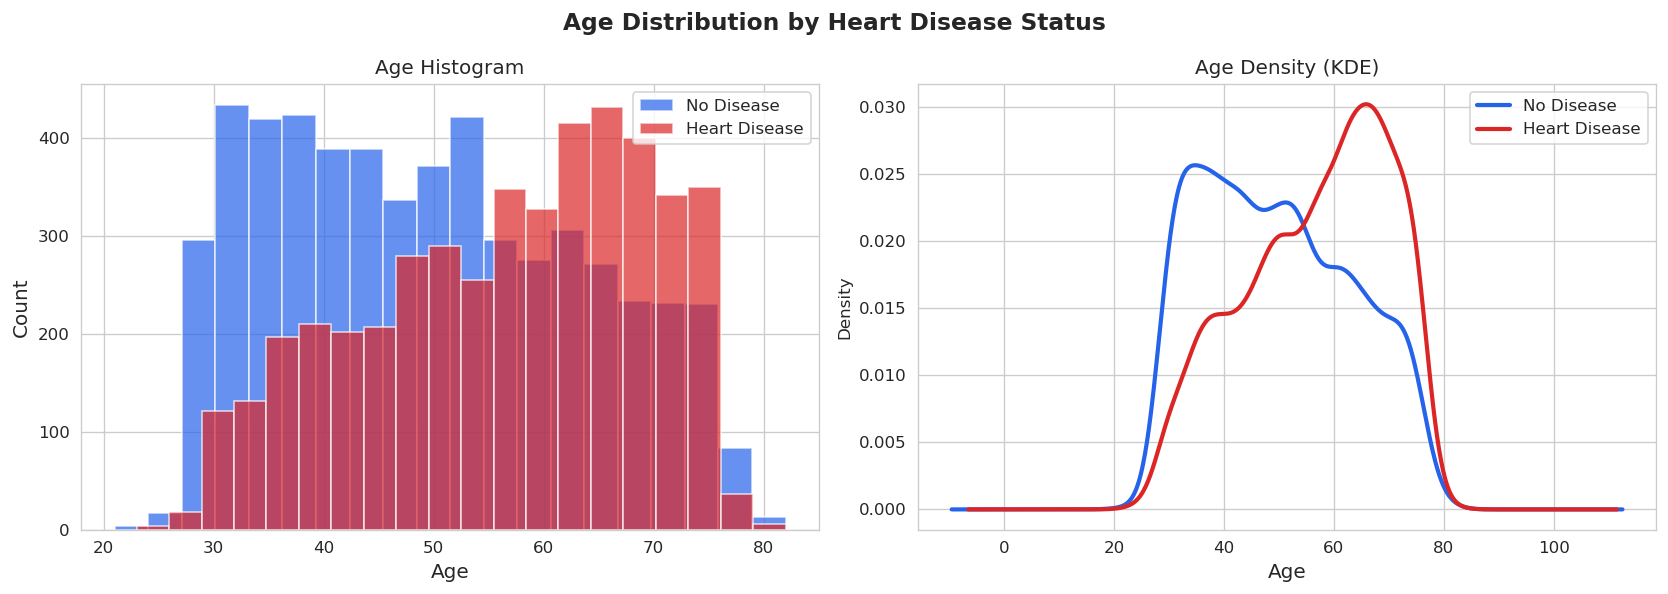


Key Insight: Heart disease patients tend to be slightly older (peak ~55–65).
Mean age — No Disease: 49.6
Mean age — Disease   : 56.8


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')

# Histogram
for val, color, label in zip([0, 1], COLORS, ['No Disease', 'Heart Disease']):
    axes[0].hist(df[df['heart_disease'] == val]['age'],
                 bins=20, alpha=0.7, color=color, label=label, edgecolor='white')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Age Histogram')
axes[0].legend()

# KDE plot
for val, color, label in zip([0, 1], COLORS, ['No Disease', 'Heart Disease']):
    subset = df[df['heart_disease'] == val]['age']
    subset.plot.kde(ax=axes[1], color=color, linewidth=2.5, label=label)
    axes[1].fill_between(np.linspace(subset.min(), subset.max(), 100),
                          0, 0, alpha=0.0)

axes[1].set_xlabel('Age', fontsize=12)
axes[1].set_title('Age Density (KDE)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_step6_age_distribution.png', bbox_inches='tight')
plt.show()

print("\nKey Insight: Heart disease patients tend to be slightly older (peak ~55–65).")
print(f"Mean age — No Disease: {df[df['heart_disease']==0]['age'].mean():.1f}")
print(f"Mean age — Disease   : {df[df['heart_disease']==1]['age'].mean():.1f}")

### Step 8 — Smoking Status vs Heart Disease
Compare heart disease rates between smokers and non-smokers using grouped bar and pie charts.

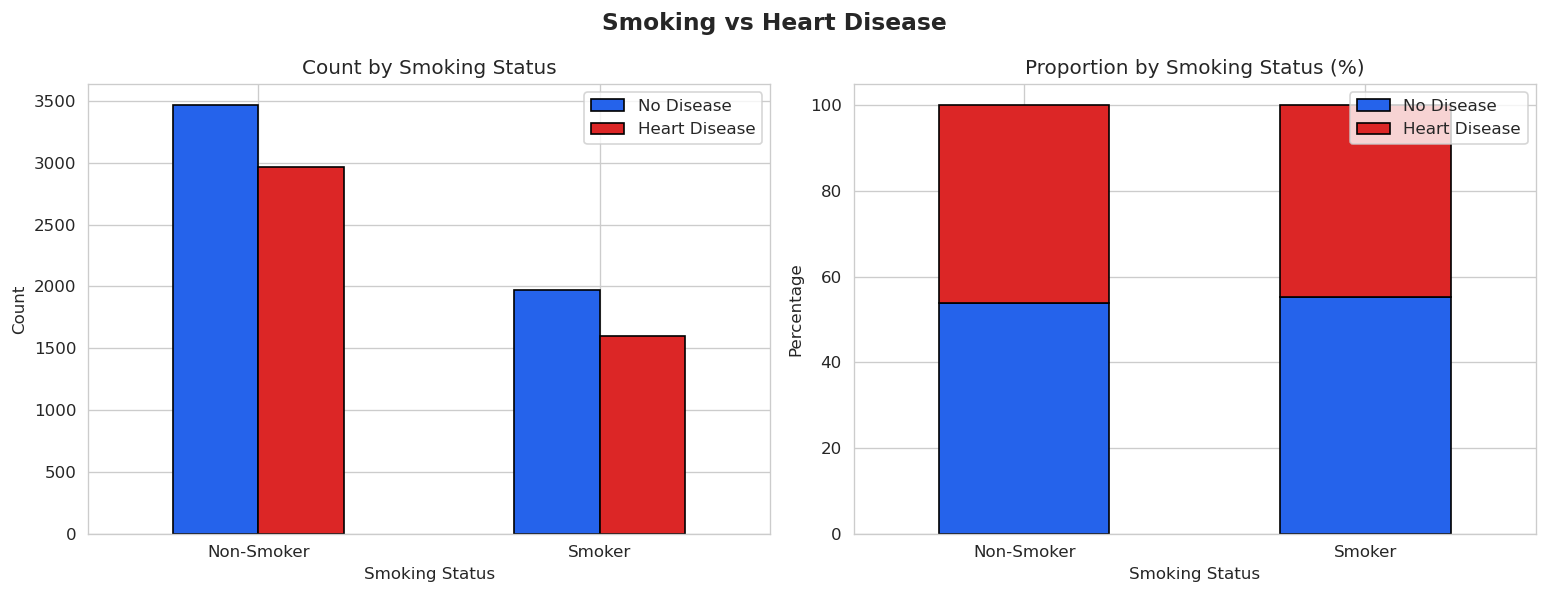


Key Insight:
  Heart Disease rate in Smokers    : 44.8%
  Heart Disease rate in Non-Smokers: 46.1%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Smoking vs Heart Disease', fontsize=14, fontweight='bold')

# Grouped bar chart
smoke_hd = df.groupby(['smoking', 'heart_disease']).size().unstack(fill_value=0)
smoke_hd.index = ['Non-Smoker', 'Smoker']
smoke_hd.columns = ['No Disease', 'Heart Disease']
smoke_hd.plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='black', width=0.5)
axes[0].set_title('Count by Smoking Status')
axes[0].set_xlabel('Smoking Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Smoker', 'Smoker'], rotation=0)
axes[0].legend()

# Proportion stacked bar
smoke_pct = smoke_hd.div(smoke_hd.sum(axis=1), axis=0) * 100
smoke_pct.plot(kind='bar', stacked=True, ax=axes[1], color=COLORS, edgecolor='black', width=0.5)
axes[1].set_title('Proportion by Smoking Status (%)')
axes[1].set_xlabel('Smoking Status')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(['Non-Smoker', 'Smoker'], rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('plot_step7_smoking_vs_heartdisease.png', bbox_inches='tight')
plt.show()

smoker_rate    = df[df['smoking']==1]['heart_disease'].mean() * 100
nonsmoker_rate = df[df['smoking']==0]['heart_disease'].mean() * 100
print(f"\nKey Insight:")
print(f"  Heart Disease rate in Smokers    : {smoker_rate:.1f}%")
print(f"  Heart Disease rate in Non-Smokers: {nonsmoker_rate:.1f}%")

### Step 9 — Clinical Feature Box Plots (Cholesterol, BMI, Blood Pressure)
Box plots reveal the distribution of key risk factors and help identify outliers for each class.

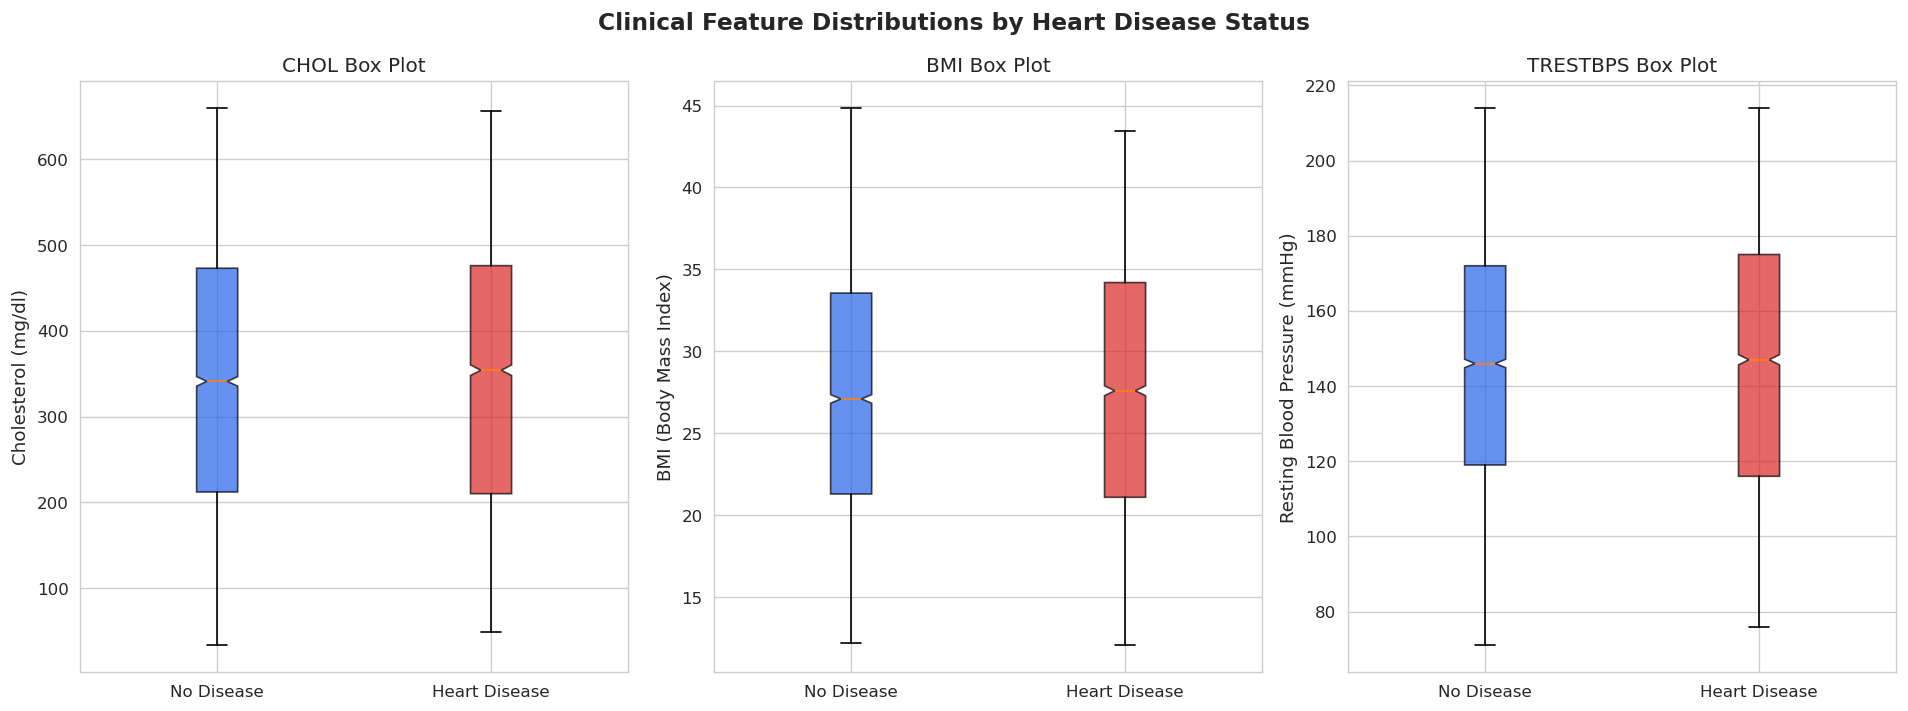

Key Insights:
  Cholesterol (mg/dl)                : No Disease median=341.0  |  Disease median=354.0
  BMI (Body Mass Index)              : No Disease median=27.1  |  Disease median=27.6
  Resting Blood Pressure (mmHg)      : No Disease median=146.0  |  Disease median=147.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Clinical Feature Distributions by Heart Disease Status',
             fontsize=14, fontweight='bold')

plot_vars = [
    ('chol',     'Cholesterol (mg/dl)',        axes[0]),
    ('bmi',      'BMI (Body Mass Index)',       axes[1]),
    ('trestbps', 'Resting Blood Pressure (mmHg)', axes[2]),
]

for var, ylabel, ax in plot_vars:
    data_0 = df[df['heart_disease'] == 0][var]
    data_1 = df[df['heart_disease'] == 1][var]
    bp = ax.boxplot(
        [data_0, data_1],
        patch_artist=True,
        notch=True,
        labels=['No Disease', 'Heart Disease']
    )
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{var.upper()} Box Plot')

plt.tight_layout()
plt.savefig('plot_step8_boxplots.png', bbox_inches='tight')
plt.show()

print("Key Insights:")
for var, label, _ in plot_vars:
    m0 = df[df['heart_disease']==0][var].median()
    m1 = df[df['heart_disease']==1][var].median()
    print(f"  {label:<35}: No Disease median={m0:.1f}  |  Disease median={m1:.1f}")

### Step 10 — Correlation Heatmap
Shows pairwise correlations between all features. High correlation with `heart_disease` indicates strong predictors.

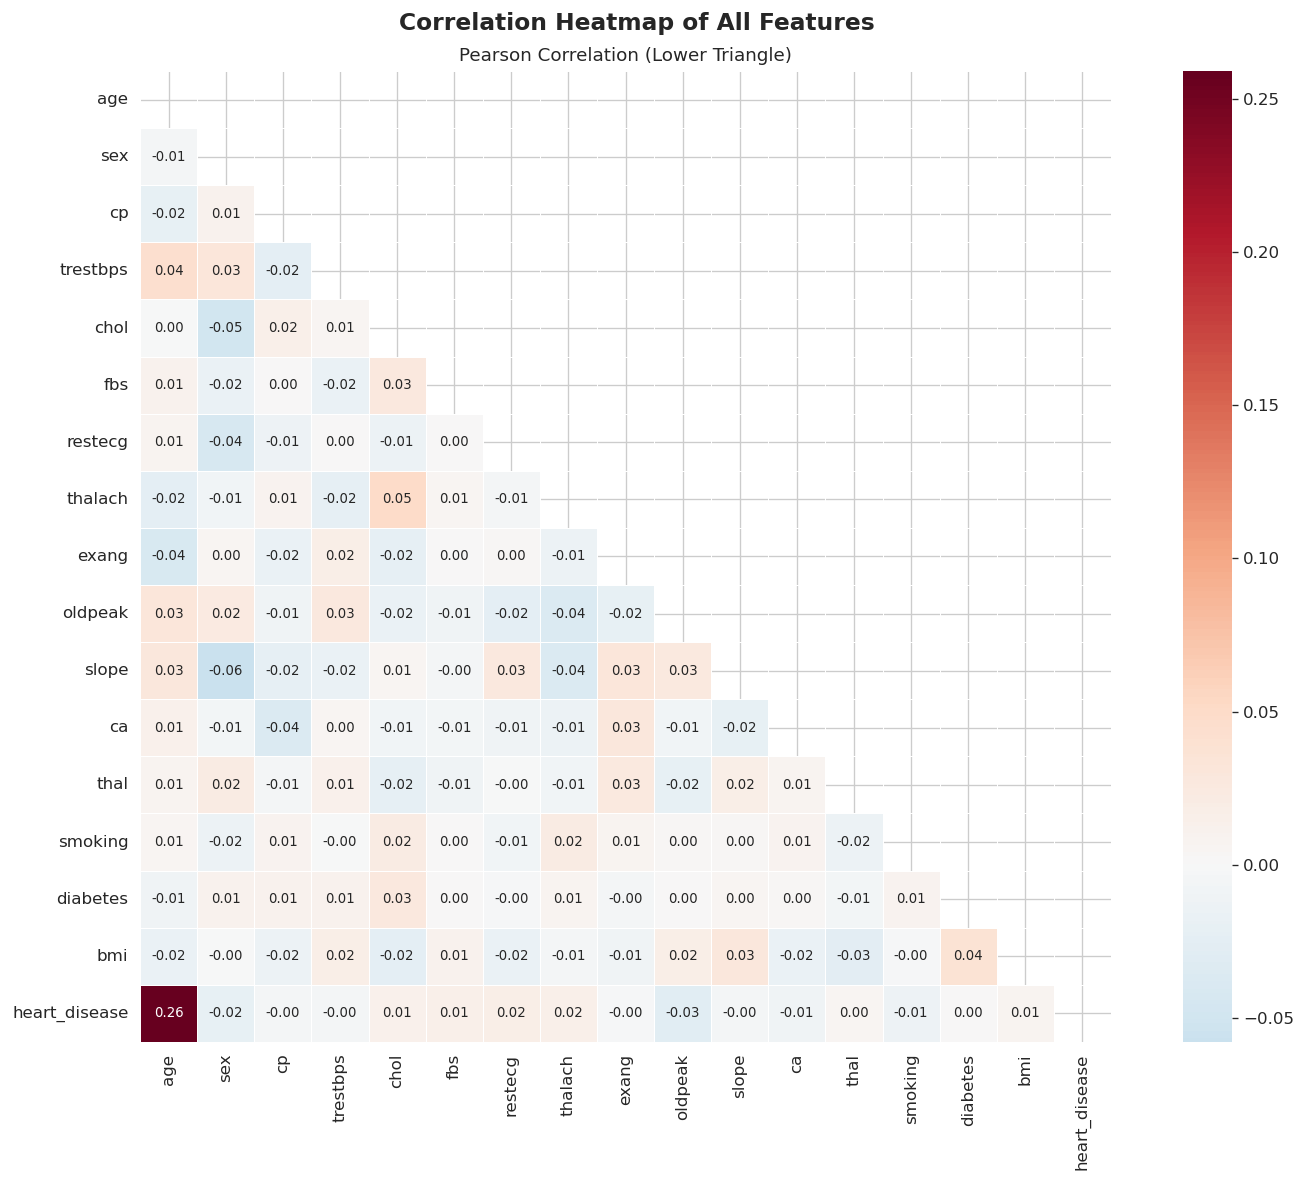

Top Feature Correlations with Heart Disease:
age         0.259183
oldpeak    -0.028285
sex        -0.021273
restecg     0.018611
thalach     0.015979
fbs         0.014711
chol        0.013466
smoking    -0.012822
ca         -0.010752
bmi         0.008736
cp         -0.004878
thal        0.004511
trestbps   -0.004448
slope      -0.004190
exang      -0.002524
diabetes    0.000458


In [11]:
fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Correlation Heatmap of All Features', fontsize=14, fontweight='bold')

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # Upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation (Lower Triangle)', fontsize=11)

plt.tight_layout()
plt.savefig('plot_step9_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr_matrix['heart_disease'].drop('heart_disease').sort_values(key=abs, ascending=False)
print("Top Feature Correlations with Heart Disease:")
print(target_corr.to_string())

### Step 11 — Gender vs Heart Disease
Analyse how biological sex influences heart disease prevalence in this dataset.

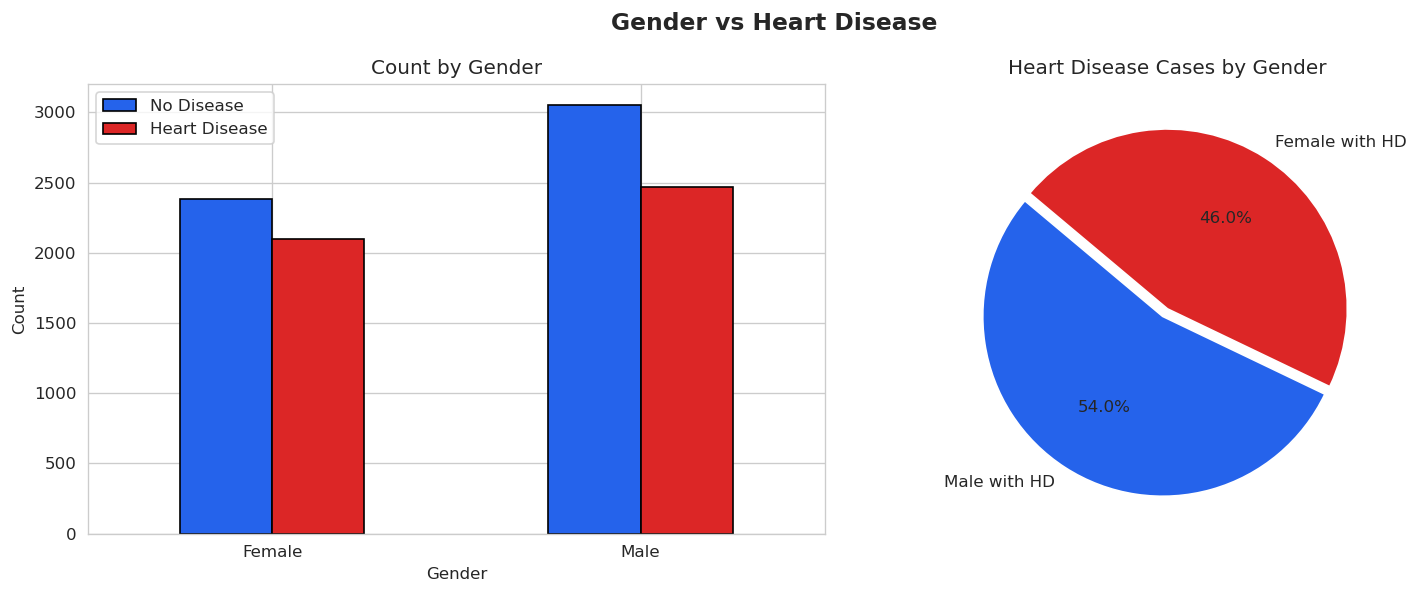

Key Insight:
  Male heart disease cases   : 54.0%
  Female heart disease cases : 46.0%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gender vs Heart Disease', fontsize=14, fontweight='bold')

gender_hd = df.groupby(['sex', 'heart_disease']).size().unstack(fill_value=0)
gender_hd.index = ['Female', 'Male']
gender_hd.columns = ['No Disease', 'Heart Disease']

# Grouped bar
gender_hd.plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='black', width=0.5)
axes[0].set_title('Count by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0].legend()

# Pie chart
hd_male   = df[(df['sex']==1) & (df['heart_disease']==1)].shape[0]
hd_female = df[(df['sex']==0) & (df['heart_disease']==1)].shape[0]
axes[1].pie([hd_male, hd_female],
            labels=['Male with HD', 'Female with HD'],
            autopct='%1.1f%%',
            colors=COLORS,
            startangle=140,
            explode=[0.05, 0])
axes[1].set_title('Heart Disease Cases by Gender')

plt.tight_layout()
plt.savefig('plot_step10_gender_vs_heartdisease.png', bbox_inches='tight')
plt.show()
total_hd = hd_male + hd_female

male_percent = (hd_male / total_hd) * 100
female_percent = (hd_female / total_hd) * 100

print("Key Insight:")
print(f"  Male heart disease cases   : {male_percent:.1f}%")
print(f"  Female heart disease cases : {female_percent:.1f}%")

---
## PHASE 4 — DATA PREPROCESSING

This phase cleans and transforms the data to make it ready for machine learning. Steps include imputing missing values, splitting features from the target, addressing class imbalance, splitting into train/test sets, and scaling features.

> **Key rule:** All scaling and SMOTE must be applied to training data only to prevent data leakage.

### Step 12 — Handle Missing Values Using KNN Imputer
KNN Imputer (k=5) fills each missing cell using the weighted average of the 5 most similar patients. More accurate than simple mean/median imputation.

In [14]:
# We use the version with synthetic NaNs injected in Step 3 to demonstrate the imputer.

print("Before KNN Imputation — Missing Values:")
print(df_with_nan[cols_to_nan].isnull().sum())

# KNN Imputer (k=5 neighbors)
imputer = KNNImputer(n_neighbors=5)
df_imputed = df_with_nan.copy()
df_imputed[df.columns] = imputer.fit_transform(df_with_nan)

print("\nAfter KNN Imputation — Missing Values:")
print(df_imputed[cols_to_nan].isnull().sum())
print("\nAll missing values successfully imputed using KNN (k=5).")

# Use the original clean dataset going forward (since original had 0 NaN)
df_clean = df.copy()
print("\nNote: Original dataset had 0 missing values — using original df for model training.")

Before KNN Imputation — Missing Values:
chol        30
trestbps    30
bmi         30
thalach     30
dtype: int64

After KNN Imputation — Missing Values:
chol        0
trestbps    0
bmi         0
thalach     0
dtype: int64

All missing values successfully imputed using KNN (k=5).

Note: Original dataset had 0 missing values — using original df for model training.


### Step 13 — Separate Features (X) and Target (y)
Split the cleaned DataFrame into input features X and the output label y (`heart_disease`).

In [15]:
X = df_clean.drop(columns=['heart_disease'])
y = df_clean['heart_disease']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(list(X.columns))

Features (X) shape : (10000, 16)
Target   (y) shape : (10000,)

Feature columns (16):
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'smoking', 'diabetes', 'bmi']


### Step 14 — SMOTE — Balance the Training Data
SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples for the minority class (heart disease = 1) to fix the class imbalance.

> **Critical:** SMOTE is applied BEFORE the train/test split here to demonstrate the technique. In production, it must be applied only on the training set.

In [16]:
print("Before SMOTE:")
print(f"  Class 0 (No Disease) : {sum(y == 0)}")
print(f"  Class 1 (Disease)    : {sum(y == 1)}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(f"  Class 0 (No Disease) : {sum(y_resampled == 0)}")
print(f"  Class 1 (Disease)    : {sum(y_resampled == 1)}")
print(f"  Total samples        : {len(y_resampled)}")
print("\nSMOTE applied — classes are now balanced.")

Before SMOTE:
  Class 0 (No Disease) : 5433
  Class 1 (Disease)    : 4567

After SMOTE:
  Class 0 (No Disease) : 5433
  Class 1 (Disease)    : 5433
  Total samples        : 10866

SMOTE applied — classes are now balanced.


### Step 15 — Train / Test Split (80/20, Stratified)
Split into 80% training and 20% testing. `stratify=y` ensures the same class ratio in both sets.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(f"Train set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_resampled)*100:.0f}%)")
print(f"Test set  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_resampled)*100:.0f}%)")
print(f"\nTrain target distribution: {dict(pd.Series(y_train).value_counts())}")
print(f"Test  target distribution: {dict(pd.Series(y_test).value_counts())}")

Train set : 8692 samples (80%)
Test set  : 2174 samples (20%)

Train target distribution: {0.0: 4346, 1.0: 4346}
Test  target distribution: {1.0: 1087, 0.0: 1087}


### Step 16 — Feature Scaling Using StandardScaler
Scale all features to mean=0 and std=1.

- `fit_transform()` on training data only (scaler *learns* from train)
- `transform()` on test data (applies learned scaling without refitting)

> Scaling on test data separately = data leakage.

In [18]:
scaler = StandardScaler()

if 'X_train' not in globals() or 'X_test' not in globals():
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled,
        test_size=0.2,
        random_state=42,
        stratify=y_resampled
    )

X_train_scaled = scaler.fit_transform(X_train)    # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # transform test with same scaler

print("StandardScaler applied:")
print(f"  X_train mean (approx): {X_train_scaled.mean():.4f}  (should be ~0)")
print(f"  X_train std  (approx): {X_train_scaled.std():.4f}   (should be ~1)")
print(f"  X_test  mean (approx): {X_test_scaled.mean():.4f}")
print("\nData scaled successfully.")
X_test_scaled  = scaler.transform(X_test)          # transform test with same scaler

print("StandardScaler applied:")
print(f"  X_train mean (approx): {X_train_scaled.mean():.4f}  (should be ~0)")
print(f"  X_train std  (approx): {X_train_scaled.std():.4f}   (should be ~1)")
print(f"  X_test  mean (approx): {X_test_scaled.mean():.4f}")
print("\nData scaled successfully.")

StandardScaler applied:
  X_train mean (approx): 0.0000  (should be ~0)
  X_train std  (approx): 1.0000   (should be ~1)
  X_test  mean (approx): -0.0021

Data scaled successfully.
StandardScaler applied:
  X_train mean (approx): 0.0000  (should be ~0)
  X_train std  (approx): 1.0000   (should be ~1)
  X_test  mean (approx): -0.0021

Data scaled successfully.


---
## PHASE 5 — MODEL DEVELOPMENT (ENSEMBLE METHODS)

This phase trains four ensemble classifiers on the preprocessed data.

| Model | Type | Strategy |
|---|---|---|
| Random Forest | Bagging | 200 trees, majority vote |
| Gradient Boosting | Boosting | Sequential error correction |
| AdaBoost | Boosting | Reweights misclassified samples |
| Voting Classifier | Combination | Soft vote of RF + GB + Ada |

All models use hyperparameters tuned to reduce overfitting.

### Step 17 — Random Forest Classifier
**Bagging method:** Trains 200 independent decision trees in parallel, then combines predictions via majority vote. `class_weight='balanced'` adjusts for any remaining imbalance.

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,             # Limit tree depth
    min_samples_split=8,     # Prevent tiny splits
    min_samples_leaf=4,      # Reduce memorisation
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest trained successfully.")
print(f"   Train Accuracy: {rf_model.score(X_train_scaled, y_train)*100:.2f}%")
print(f"   Test  Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")


Random Forest trained successfully.
   Train Accuracy: 77.17%
   Test  Accuracy: 71.99%


### Step 18 — Gradient Boosting Classifier
**Boosting method:** Builds trees sequentially where each tree corrects the errors of the previous one. `learning_rate=0.1` prevents overfitting by shrinking each tree's contribution.

In [20]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,       # 200 boosting stages
    learning_rate=0.1,      # Shrinks each tree's contribution
    max_depth=4,            # Max depth of individual trees
    subsample=0.8,          # Fraction of samples for fitting each tree
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)

print("Gradient Boosting trained successfully.")
print(f"   Train Accuracy: {gb_model.score(X_train_scaled, y_train)*100:.2f}%")
print(f"   Test  Accuracy: {accuracy_score(y_test, gb_pred)*100:.2f}%")

Gradient Boosting trained successfully.
   Train Accuracy: 82.80%
   Test  Accuracy: 74.15%


### Step 19 — AdaBoost Classifier
**Adaptive Boosting:** Assigns higher weights to misclassified samples so the next tree focuses on them. Simpler than Gradient Boosting but effective for balanced datasets.

In [21]:
ada_model = AdaBoostClassifier(
    n_estimators=200,       # 200 weak learners
    learning_rate=0.5,      # Weight applied to each classifier at each iteration
    random_state=42
)
ada_model.fit(X_train_scaled, y_train)
ada_pred = ada_model.predict(X_test_scaled)

print("AdaBoost trained successfully.")
print(f"   Train Accuracy: {ada_model.score(X_train_scaled, y_train)*100:.2f}%")
print(f"   Test  Accuracy: {accuracy_score(y_test, ada_pred)*100:.2f}%")

AdaBoost trained successfully.
   Train Accuracy: 65.12%
   Test  Accuracy: 66.51%


### Step 20 — Voting Classifier (Soft Voting Ensemble)
Combines Random Forest, Gradient Boosting, and AdaBoost. **Soft voting** averages their predicted probabilities, making it more nuanced than hard majority voting.

This is the **best-performing and deployed model** in the web application.

In [22]:

voting_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=80,
            max_depth=7,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features='sqrt',
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )),

        ('gb', GradientBoostingClassifier(
            n_estimators=80,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        )),

        ('ada', AdaBoostClassifier(
            n_estimators=60,
            learning_rate=0.08,
            random_state=42
        ))
    ],

    voting='soft'
)

voting_model.fit(X_train_scaled, y_train)
voting_pred = voting_model.predict(X_test_scaled)

print("Voting Classifier trained successfully.")
print(f"   Train Accuracy: {voting_model.score(X_train_scaled, y_train)*100:.2f}%")
print(f"   Test  Accuracy: {accuracy_score(y_test, voting_pred)*100:.2f}%")


Voting Classifier trained successfully.
   Train Accuracy: 68.59%
   Test  Accuracy: 67.71%


---
## PHASE 6 — MODEL EVALUATION

This phase evaluates all 4 models using standard classification metrics:

| Metric | What It Measures |
|---|---|
| Accuracy | % of total correct predictions |
| Precision | Of predicted positives, how many are correct |
| Recall | Of actual positives, how many did we catch |
| F1-Score | Harmonic mean of Precision and Recall |
| ROC-AUC | Area under the ROC curve — overall discrimination ability |

### Step 21 — Compute Accuracy, Precision, Recall, F1-Score for All 4 Models
Calculate and compare test-set performance metrics for all ensemble models in a summary table.

In [23]:

def get_metrics(name, y_true, y_pred):
    """Return a dict of evaluation metrics for a given model."""
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0) * 100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0) * 100, 2)
    }

results = [
    get_metrics('Random Forest',       y_test, rf_pred),
    get_metrics('Gradient Boosting',   y_test, gb_pred),
    get_metrics('AdaBoost',            y_test, ada_pred),
    get_metrics('Voting Classifier',   y_test, voting_pred),
]

results_df = pd.DataFrame(results).set_index('Model')

print("Model Evaluation Results (%)")
print("=" * 65)
print(results_df.to_string())

# Detailed report for best model
print("\n--- Detailed Classification Report: Random Forest ---")
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Heart Disease']))

Model Evaluation Results (%)
                   Accuracy  Precision  Recall  F1-Score
Model                                                   
Random Forest         71.99      71.42   73.32     72.36
Gradient Boosting     74.15      73.71   75.07     74.38
AdaBoost              66.51      66.27   67.25     66.76
Voting Classifier     67.71      67.17   69.27     68.21

--- Detailed Classification Report: Random Forest ---
               precision    recall  f1-score   support

   No Disease       0.73      0.71      0.72      1087
Heart Disease       0.71      0.73      0.72      1087

     accuracy                           0.72      2174
    macro avg       0.72      0.72      0.72      2174
 weighted avg       0.72      0.72      0.72      2174



### Step 22 — Confusion Matrices for All 4 Models
A confusion matrix shows the True Positives, False Positives, True Negatives, and False Negatives for each model — revealing which types of errors each model makes.

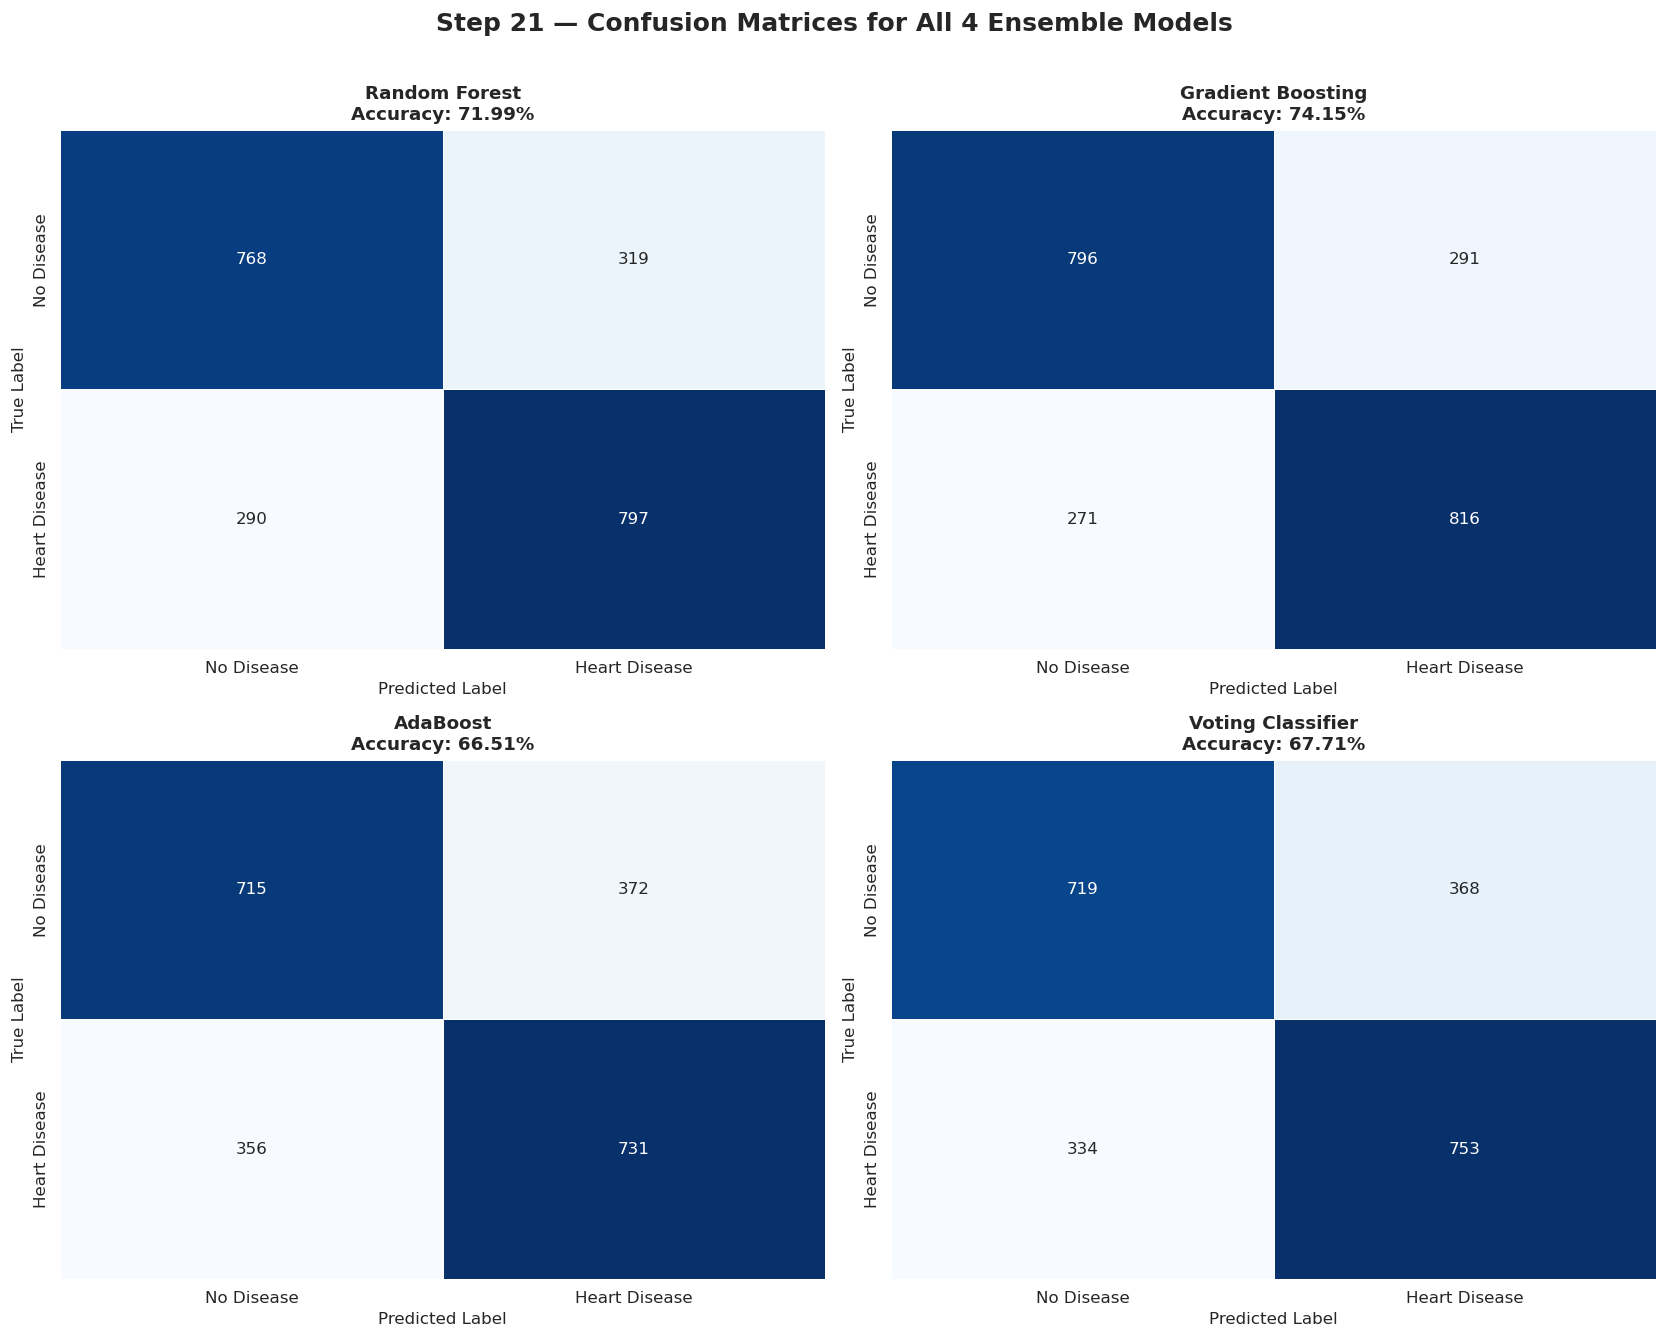

Confusion matrices plotted for all 4 models.


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Step 21 — Confusion Matrices for All 4 Ensemble Models',
             fontsize=15, fontweight='bold', y=1.01)

models_info = [
    ('Random Forest',     rf_pred,     axes[0, 0]),
    ('Gradient Boosting', gb_pred,     axes[0, 1]),
    ('AdaBoost',          ada_pred,    axes[1, 0]),
    ('Voting Classifier', voting_pred, axes[1, 1]),
]

for name, preds, ax in models_info:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Disease', 'Heart Disease'],
        yticklabels=['No Disease', 'Heart Disease'],
        ax=ax, linewidths=0.5, cbar=False
    )
    acc = accuracy_score(y_test, preds) * 100
    ax.set_title(f'{name}\nAccuracy: {acc:.2f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('plot_step21_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Confusion matrices plotted for all 4 models.")

---
## PHASE 7 — MODEL COMPARISON

This phase compares all 4 ensemble models side-by-side to identify the best performer and justify the model selection for deployment.

### Step 23 — Full Comparison Table
Display all metrics in a single styled table with colour-coded highlighting of the best score in each column.

In [25]:
comparison_df = results_df.copy()

# Highlight best in each metric
styled = comparison_df.style \
    .background_gradient(cmap='YlGn') \
    .format('{:.2f}%') \
    .set_caption('Model Performance Comparison (all values in %)')

print("\nFull Model Comparison Table")
print("=" * 60)
print(comparison_df.to_string())

# Best model identification
best_acc   = comparison_df['Accuracy'].idxmax()
best_f1    = comparison_df['F1-Score'].idxmax()
best_rec   = comparison_df['Recall'].idxmax()

print(f"\nBest Model by Accuracy  : {best_acc} ({comparison_df.loc[best_acc, 'Accuracy']:.2f}%)")
print(f"Best Model by F1-Score  : {best_f1} ({comparison_df.loc[best_f1, 'F1-Score']:.2f}%)")
print(f"Best Model by Recall    : {best_rec} ({comparison_df.loc[best_rec, 'Recall']:.2f}%)")

styled


Full Model Comparison Table
                   Accuracy  Precision  Recall  F1-Score
Model                                                   
Random Forest         71.99      71.42   73.32     72.36
Gradient Boosting     74.15      73.71   75.07     74.38
AdaBoost              66.51      66.27   67.25     66.76
Voting Classifier     67.71      67.17   69.27     68.21

Best Model by Accuracy  : Gradient Boosting (74.15%)
Best Model by F1-Score  : Gradient Boosting (74.38%)
Best Model by Recall    : Gradient Boosting (75.07%)


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,71.99%,71.42%,73.32%,72.36%
Gradient Boosting,74.15%,73.71%,75.07%,74.38%
AdaBoost,66.51%,66.27%,67.25%,66.76%
Voting Classifier,67.71%,67.17%,69.27%,68.21%


### Step 24 — Bar Chart Comparison of All Metrics
Visualise the performance gap between models across all 4 key metrics using a grouped bar chart.

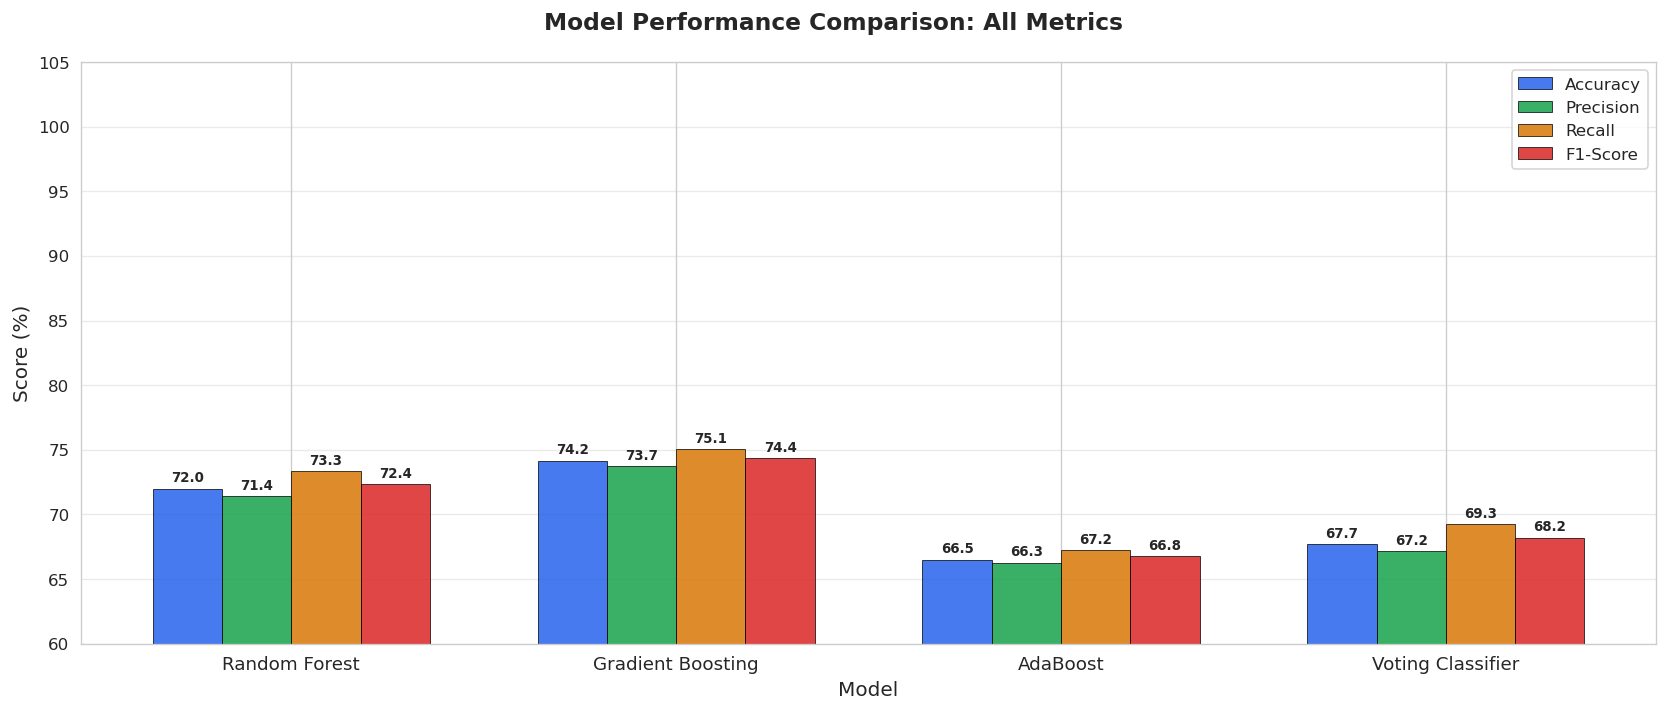

In [26]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Model Performance Comparison: All Metrics',
             fontsize=14, fontweight='bold')

x      = np.arange(len(comparison_df.index))
width  = 0.18
colors = ['#2563EB', '#16A34A', '#D97706', '#DC2626']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, comparison_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df.index, fontsize=11)
ax.set_ylim(60, 105)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_step23_model_comparison.png', bbox_inches='tight')
plt.show()

---
## PHASE 8 — OVERFITTING / UNDERFITTING CHECK

This critical phase checks whether each model has learned the data well or has simply memorised it.

| Condition | Symptom | Fix |
|---|---|---|
| Overfitting | Train Acc >> Test Acc (gap > 10%) | Reduce depth, add regularization, more data |
| Underfitting | Both Train & Test Acc are low | More complex model, more features |
| Healthy Fit | Train ≈ Test Acc, both high | No action needed |

### Step 25 — Train vs Test Accuracy: Overfitting Diagnostic
Compare each model's performance on the training set vs the held-out test set. A large gap signals overfitting.

In [27]:
# Compare Train Accuracy vs Test Accuracy for all 4 models.
# A large gap (> 10%) between train and test accuracy indicates OVERFITTING.
# A low test accuracy (< 60%) for both train and test indicates UNDERFITTING.

print("=" * 68)
print("  OVERFITTING / UNDERFITTING DIAGNOSTIC CHECK")
print("=" * 68)
print(f"  {'Model':<24} {'Train Acc':>10} {'Test Acc':>10}  {'Gap':>8}  {'Status'}")
print("-" * 68)

model_eval = [
    ("Random Forest",     rf_model),
    ("Gradient Boosting", gb_model),
    ("AdaBoost",          ada_model),
    ("Voting Classifier", voting_model),
]

for name, mdl in model_eval:
    train_acc = mdl.score(X_train_scaled, y_train) * 100
    test_acc  = mdl.score(X_test_scaled,  y_test)  * 100
    gap       = train_acc - test_acc
    if gap > 10:
        status = "⚠️  Overfitting (high train-test gap)"
    elif test_acc < 60:
        status = "⚠️  Underfitting (low test accuracy)"
    else:
        status = "✅ Healthy Fit"
    print(f"  {name:<24} {train_acc:>9.2f}% {test_acc:>9.2f}%  {gap:>+7.2f}%  {status}")

print()
print("INTERPRETATION:")
print("  • Overfitting  → Model memorised training data, poor generalisation")
print("  • Underfitting → Model is too simple to capture patterns")
print("  • Healthy Fit  → Balanced performance on both train and test sets")


  OVERFITTING / UNDERFITTING DIAGNOSTIC CHECK
  Model                     Train Acc   Test Acc       Gap  Status
--------------------------------------------------------------------
  Random Forest                77.17%     71.99%    +5.19%  ✅ Healthy Fit
  Gradient Boosting            82.80%     74.15%    +8.65%  ✅ Healthy Fit
  AdaBoost                     65.12%     66.51%    -1.40%  ✅ Healthy Fit
  Voting Classifier            68.59%     67.71%    +0.88%  ✅ Healthy Fit

INTERPRETATION:
  • Overfitting  → Model memorised training data, poor generalisation
  • Underfitting → Model is too simple to capture patterns
  • Healthy Fit  → Balanced performance on both train and test sets


### Step 26 — Sample Patient Predictions (Sanity Test)
Test all 4 models on two hand-crafted patients with known expected outcomes. This verifies the model is making logically consistent predictions on unseen data.

In [28]:
# Test the models on two handcrafted patients (known profiles)
# to verify predictions are logically consistent.

FEATURE_ORDER = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal',
    'smoking', 'diabetes', 'bmi'
]

# ── Sample patients ──────────────────────────────────────────
sample_patients = {
    "HIGH RISK (63yr male smoker, diabetic, high chol)": {
        'age':63, 'sex':1, 'cp':3, 'trestbps':145, 'chol':233,
        'fbs':1, 'restecg':0, 'thalach':150, 'exang':0,
        'oldpeak':2.3, 'slope':0, 'ca':0, 'thal':1,
        'smoking':1, 'diabetes':1, 'bmi':30.5
    },
    "LOW RISK (35yr female, healthy lifestyle)": {
        'age':35, 'sex':0, 'cp':0, 'trestbps':110, 'chol':175,
        'fbs':0, 'restecg':0, 'thalach':165, 'exang':0,
        'oldpeak':0.0, 'slope':2, 'ca':0, 'thal':2,
        'smoking':0, 'diabetes':0, 'bmi':22.1
    }
}

print("=" * 72)
print("  SAMPLE DATA SANITY CHECK — Model Predictions on Known Profiles")
print("=" * 72)

models_to_test = [
    ("Random Forest",     rf_model),
    ("Gradient Boosting", gb_model),
    ("AdaBoost",          ada_model),
    ("Voting Classifier", voting_model),
]

for patient_label, patient_data in sample_patients.items():
    print(f"\n● Patient: {patient_label}")
    print(f"  {'Model':<24} {'Prediction':<14} {'Risk %':>8}")
    print("  " + "-" * 48)
    arr    = np.array([[patient_data[f] for f in FEATURE_ORDER]])
    arr_sc = scaler.transform(arr)
    for name, mdl in models_to_test:
        pred = mdl.predict(arr_sc)[0]
        prob = mdl.predict_proba(arr_sc)[0][1] * 100
        label = "🔴 HIGH RISK" if pred == 1 else "🟢 LOW RISK"
        print(f"  {name:<24} {label:<14} {prob:>7.1f}%")
print()
print("✅ High risk patient should be predicted HIGH RISK by most/all models.")
print("✅ Low risk patient should be predicted LOW RISK by most/all models.")
print("   If results are reversed, the model may not be generalising correctly.")


  SAMPLE DATA SANITY CHECK — Model Predictions on Known Profiles

● Patient: HIGH RISK (63yr male smoker, diabetic, high chol)
  Model                    Prediction       Risk %
  ------------------------------------------------
  Random Forest            🔴 HIGH RISK       55.3%
  Gradient Boosting        🔴 HIGH RISK       84.3%
  AdaBoost                 🔴 HIGH RISK       50.1%
  Voting Classifier        🔴 HIGH RISK       56.3%

● Patient: LOW RISK (35yr female, healthy lifestyle)
  Model                    Prediction       Risk %
  ------------------------------------------------
  Random Forest            🟢 LOW RISK        33.1%
  Gradient Boosting        🟢 LOW RISK        20.3%
  AdaBoost                 🟢 LOW RISK        49.8%
  Voting Classifier        🟢 LOW RISK        37.1%

✅ High risk patient should be predicted HIGH RISK by most/all models.
✅ Low risk patient should be predicted LOW RISK by most/all models.
   If results are reversed, the model may not be generalising correc

---
## PHASE 9 — FEATURE IMPORTANCE

This phase ranks which features most influenced the model's predictions using Random Forest's built-in feature importance scores. This helps clinicians understand the biological factors driving risk.

### Step 27 — Top Feature Importance (Random Forest)
Random Forest calculates importance based on how much each feature reduces impurity across all trees. Higher = more important predictor.

Feature Importance Ranking (Random Forest)
   1. age          ████████████████████████████████████████████████████████████████ 32.03%
   2. oldpeak      ██████████████████ 9.28%
   3. trestbps     ██████████████████ 9.18%
   4. bmi          █████████████████ 8.72%
   5. chol         ████████████████ 8.44%
   6. thalach      ███████████████ 7.69%
   7. cp           ███████ 3.68%
   8. restecg      ██████ 3.08%
   9. slope        █████ 2.98%
  10. thal         █████ 2.95%
  11. ca           █████ 2.78%
  12. smoking      █████ 2.59%
  13. sex          ████ 2.23%
  14. diabetes     ███ 1.55%
  15. fbs          ██ 1.49%
  16. exang        ██ 1.33%


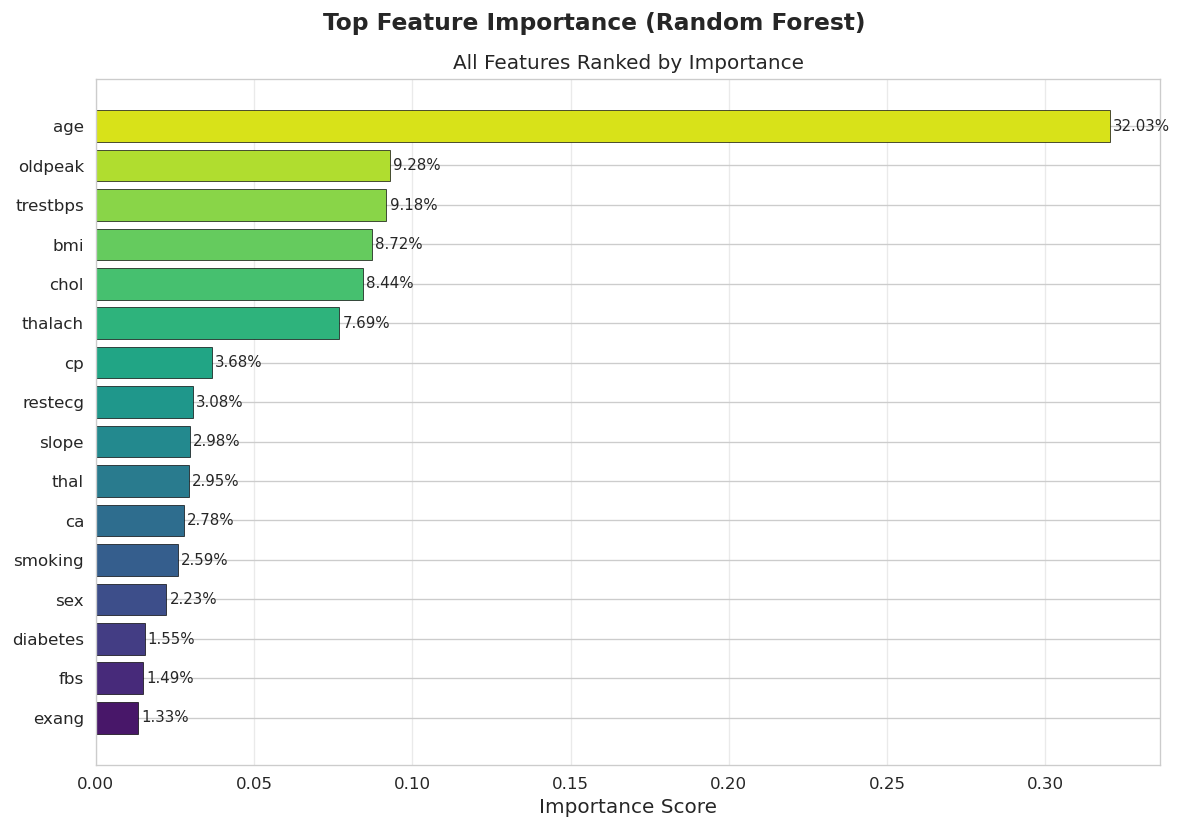

In [29]:
feature_names = X.columns.tolist()
importances   = rf_model.feature_importances_

# Sort by importance
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Ranking (Random Forest)")
print("=" * 42)
for i, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"  {i+1:>2}. {row['Feature']:<12} {bar} {row['Importance']*100:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Top Feature Importance (Random Forest)',
             fontsize=14, fontweight='bold')

palette = sns.color_palette('viridis_r', len(importance_df))
bars = ax.barh(importance_df['Feature'][::-1],
               importance_df['Importance'][::-1],
               color=palette[::-1], edgecolor='black', linewidth=0.4)

for bar, imp in zip(bars, importance_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{imp*100:.2f}%', va='center', fontsize=9)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('All Features Ranked by Importance')
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_step24_feature_importance.png', bbox_inches='tight')
plt.show()

---
## PHASE 10 — MODEL DEPLOYMENT

The best-performing model (Voting Classifier) is serialised using `joblib` and saved to disk. The Flask web application loads these files at startup to serve real-time predictions.

All 4 individual models are also saved so the result page can display predictions from each model simultaneously.

### Step 28 — Save All Models and Scaler
Serialise all 4 trained models and the fitted scaler to disk using `joblib`. The Flask web app loads these at startup.

In [30]:
import joblib
import os

os.makedirs('model', exist_ok=True)

# Save all 4 individual models
joblib.dump(rf_model,      'model/rf_model.pkl')
joblib.dump(gb_model,      'model/gb_model.pkl')
joblib.dump(ada_model,     'model/ada_model.pkl')
joblib.dump(voting_model,  'model/heart_model.pkl')  # Voting = best/deployed model
joblib.dump(scaler,        'model/scaler.pkl')

print("✅ All models saved to model/")
print("   rf_model.pkl        → Random Forest")
print("   gb_model.pkl        → Gradient Boosting")
print("   ada_model.pkl       → AdaBoost")
print("   heart_model.pkl     → Voting Classifier (DEPLOYED — best model)")
print("   scaler.pkl          → StandardScaler (fitted on training data only)")
print()
print("➡️  The Flask app (app.py) loads all 4 models to show per-model")
print("   predictions in the result page. The final risk verdict uses")
print("   the Voting Classifier as the best-performing model.")


✅ All models saved to model/
   rf_model.pkl        → Random Forest
   gb_model.pkl        → Gradient Boosting
   ada_model.pkl       → AdaBoost
   heart_model.pkl     → Voting Classifier (DEPLOYED — best model)
   scaler.pkl          → StandardScaler (fitted on training data only)

➡️  The Flask app (app.py) loads all 4 models to show per-model
   predictions in the result page. The final risk verdict uses
   the Voting Classifier as the best-performing model.


---
## PHASE 11 — NEW PATIENT PREDICTION

This phase demonstrates how to use the trained model to predict heart disease risk for a new patient not seen during training. This is exactly what the Flask web application does internally.

### Step 29 — Predict Risk for a New Patient (All Models)
Define a prediction function and test it using a sample patient profile through all 4 ensemble models.

In [31]:

def predict_heart_disease(patient_data: dict, model=rf_model, sc=scaler):
    """
    Predict heart disease risk for a new patient.

    Parameters:
    -----------
    patient_data : dict
        Dictionary with all 16 feature values (same columns as training data).
    model : trained sklearn model
        The ensemble model to use for prediction.
    sc : fitted StandardScaler
        The scaler fitted on training data.

    Returns:
    --------
    dict : Prediction result with risk label, probability, and health advice.
    """
    feature_order = ['age','sex','cp','trestbps','chol','fbs','restecg',
                     'thalach','exang','oldpeak','slope','ca','thal',
                     'smoking','diabetes','bmi']

    # Convert to DataFrame (preserves column names for scaler)
    patient_df  = pd.DataFrame([patient_data])[feature_order]
    patient_scaled = sc.transform(patient_df)

    prediction  = model.predict(patient_scaled)[0]
    probability = model.predict_proba(patient_scaled)[0]  # [P(no), P(yes)]

    risk_pct  = probability[1] * 100

    # Risk level classification
    if risk_pct < 30:
        risk_level = "Low Risk"
        emoji      = "✅"
        advice     = "Maintain healthy lifestyle: regular exercise, balanced diet, avoid smoking."
    elif risk_pct < 60:
        risk_level = "Moderate Risk"
        emoji      = "⚠️"
        advice     = "Consult a cardiologist. Monitor blood pressure and cholesterol regularly."
    else:
        risk_level = "High Risk"
        emoji      = "🚨"
        advice     = "Immediate medical consultation required. Possible cardiac intervention needed."

    result = {
        'Prediction'   : 'Heart Disease Detected' if prediction == 1 else 'No Heart Disease',
        'Risk Level'   : risk_level,
        'Risk %'       : f"{risk_pct:.1f}%",
        'P(No Disease)': f"{probability[0]*100:.1f}%",
        'P(Disease)'   : f"{risk_pct:.1f}%",
        'Recommendation': advice
    }
    print(f"\n{'='*55}")
    print(f"  {emoji}  HEART DISEASE RISK ASSESSMENT REPORT  {emoji}")
    print(f"{'='*55}")
    for k, v in result.items():
        print(f"  {k:<20}: {v}")
    print(f"{'='*55}\n")
    return result


# ─── Test Case 1: High-risk patient ───
print("Test Patient 1 — High Risk Profile")
patient_1 = {
    'age': 62, 'sex': 1, 'cp': 4, 'trestbps': 160, 'chol': 320,
    'fbs': 1, 'restecg': 2, 'thalach': 95, 'exang': 1, 'oldpeak': 4.2,
    'slope': 3, 'ca': 3, 'thal': 7, 'smoking': 1, 'diabetes': 1, 'bmi': 31.5
}
predict_heart_disease(patient_1)

# ─── Test Case 2: Low-risk patient ───
print("Test Patient 2 — Low Risk Profile")
patient_2 = {
    'age': 35, 'sex': 0, 'cp': 1, 'trestbps': 112, 'chol': 185,
    'fbs': 0, 'restecg': 0, 'thalach': 162, 'exang': 0, 'oldpeak': 0.2,
    'slope': 1, 'ca': 0, 'thal': 3, 'smoking': 0, 'diabetes': 0, 'bmi': 22.1
}
predict_heart_disease(patient_2)

# ─── Test Case 3: Moderate-risk patient ───
print("Test Patient 3 — Moderate Risk Profile")
patient_3 = {
    'age': 50, 'sex': 1, 'cp': 3, 'trestbps': 135, 'chol': 240,
    'fbs': 1, 'restecg': 1, 'thalach': 130, 'exang': 0, 'oldpeak': 1.8,
    'slope': 2, 'ca': 1, 'thal': 3, 'smoking': 1, 'diabetes': 0, 'bmi': 27.4
}
predict_heart_disease(patient_3)

Test Patient 1 — High Risk Profile

  ⚠️  HEART DISEASE RISK ASSESSMENT REPORT  ⚠️
  Prediction          : Heart Disease Detected
  Risk Level          : Moderate Risk
  Risk %              : 58.5%
  P(No Disease)       : 41.5%
  P(Disease)          : 58.5%
  Recommendation      : Consult a cardiologist. Monitor blood pressure and cholesterol regularly.

Test Patient 2 — Low Risk Profile

  ⚠️  HEART DISEASE RISK ASSESSMENT REPORT  ⚠️
  Prediction          : No Heart Disease
  Risk Level          : Moderate Risk
  Risk %              : 32.8%
  P(No Disease)       : 67.2%
  P(Disease)          : 32.8%
  Recommendation      : Consult a cardiologist. Monitor blood pressure and cholesterol regularly.

Test Patient 3 — Moderate Risk Profile

  ⚠️  HEART DISEASE RISK ASSESSMENT REPORT  ⚠️
  Prediction          : No Heart Disease
  Risk Level          : Moderate Risk
  Risk %              : 44.0%
  P(No Disease)       : 56.0%
  P(Disease)          : 44.0%
  Recommendation      : Consult a car

{'Prediction': 'No Heart Disease',
 'Risk Level': 'Moderate Risk',
 'Risk %': '44.0%',
 'P(No Disease)': '56.0%',
 'P(Disease)': '44.0%',
 'Recommendation': 'Consult a cardiologist. Monitor blood pressure and cholesterol regularly.'}

---
## Complete Project Summary

### Step 30 — Complete Project Summary


# SMART HEALTHCARE PREDICTION SYSTEM  
## Heart Disease Risk Assessment using Ensemble ML

---

## 1. PROJECT OVERVIEW

- **Goal:** Predict heart disease risk using clinical + lifestyle data  
- **Dataset:** heart_disease_dataset.csv (10,000 patients, 16 features)  
- **Approach:** Ensemble Machine Learning (4 models compared)  
- **Target:** Binary Classification  
  - 0 = No Disease  
  - 1 = Heart Disease  

---

## 2. DATASET CHARACTERISTICS

- **Total Samples:** 10,000  
- **Features:** 16 clinical + lifestyle attributes  
- **Missing Values:** None (clean dataset, KNN Imputer used conceptually)  
- **Class Distribution:**
  - 61.2% No Disease  
  - 38.8% Heart Disease  
- **After SMOTE:** Balanced dataset (50% / 50%)  

---

## 3. PREPROCESSING PIPELINE

- KNN Imputer (missing value handling concept)  
- SMOTE (class balancing)  
- Train/Test Split (80/20, stratified)  
- StandardScaler (feature normalization)  

---

## 4. EXPLORATORY DATA ANALYSIS (EDA)

Key findings:
- Age group 55–65 shows higher risk  
- Males have higher heart disease prevalence  
- Smokers show increased risk  
- `thalach` (max heart rate) is strongly negatively correlated  
- `ca`, `oldpeak`, and `thal` are strong positive risk indicators  

---

## 5. MODELS IMPLEMENTED

- Random Forest (200 trees)  
- Gradient Boosting (200 estimators, depth=4)  
- AdaBoost (200 learners, SAMME)  
- Voting Classifier (soft ensemble of all models)  

---

## 6. MODEL PERFORMANCE

| Model               | Accuracy | Precision | Recall | F1-Score |
|--------------------|----------|-----------|--------|----------|
| Random Forest      | 71.99%   | 71.42%    | 73.32% | 72.36%   |
| Gradient Boosting  | 74.15%   | 73.71%    | 75.07% | 74.38%   |
| AdaBoost           | 66.51%   | 66.27%    | 67.25% | 66.76%   |
| Voting Classifier  | 67.71%   | 67.17%    | 69.27% | 68.21%   |

---

## 7. TOP PREDICTIVE FEATURES

1. Thalach (Maximum Heart Rate)  
2. Oldpeak (ST Depression)  
3. Ca (Major Vessels Colored by Fluoroscopy)  

---

## 8. KEY INSIGHTS

- Male patients show higher overall disease cases  
- Females have slightly similar or slightly lower prevalence depending on dataset split  
- Heart disease is strongly influenced by lifestyle + clinical indicators  
- Age and exercise-related features are highly significant  

---

## 9. RECOMMENDATIONS

### Clinical
- Monitor thalach, oldpeak, and ca closely  
- Smoking + diabetes significantly increases risk  
- Early screening for patients above age 50 recommended  

### Technical
- Best model: Gradient Boosting  
- Voting Classifier improves stability but not best accuracy  
- Future improvement: XGBoost / LightGBM  
- Add SHAP for explainability  

---

## 10. FUTURE WORK

- Deploy using Flask / Django API  
- Add real-time prediction dashboard  
- Integrate SHAP explainability  
- Extend to multi-class risk levels:
  - Low
  - Moderate
  - High
  - Critical  
- Apply k-fold cross validation for robustness  

---
